# 2. What the interpolation rule does to a curve

## Objective

Notebook 01 built one curve from seven quotes using the canonical interpolation
rule, log-linear on discount factors, and verified that it reprices every quote
exactly. That choice is not innocuous. Seven quotes constrain the discount
function at seven points; everywhere else the curve is whatever the
interpolation rule says it is, and a ten year bond pays on dates that are almost
all in the "everywhere else" region.

This notebook builds the same SEK government curve under all three rules the
library implements. The canonical log-linear curve is built first, exactly as in
notebook 01; the cubic log-DF and Hagan-West monotone convex curves are then
built as *overlays* on the canonical curve's nodes — the same discount factors
at the same pillars, re-interpolated with the comparative rule. Nothing about
the input changes between the three curves below; only the rule for filling the
gaps changes.

Because the overlays share the canonical nodes, they agree with the canonical
curve *at the pillars by construction*. The interesting quantities are therefore
the values between pillars, where the rules disagree, and the final quote
residuals, which the canonical build drives to zero and the overlays leave as
measured, typically nonzero, numbers.

## Data

Identical to notebook 01: three Riksbank treasury bill quotes and four government
benchmark yields from the committed snapshot `data/snapshots/2026-07-24/`.
Nothing about the input changes between the three curves below. Only the rule for
filling the gaps changes.

## Theory

Every curve is a choice. Seven quotes constrain the discount function at seven
points; infinitely many functions pass through those points. The interpolation
rule selects one. The canonical log-linear curve reprices the seven instruments
exactly (that is its contract); the overlays' final residuals are measured below
and are small but nonzero. All three curves agree where the quotes are and
differ elsewhere.

A key difference is **locality**: how far does changing one quote propagate? A
log-linear scheme is local. Moving one pillar changes only the immediately
adjacent intervals; the curve elsewhere is unaffected. A natural cubic spline is
global: its coefficients solve a linear system coupling all knots to all others,
so moving one quote perturbs the entire curve, including regions far from the
knot. This matters to risk: a risk desk bumps one pillar to measure its exposure.
Under a local scheme the bump affects only two adjacent buckets; under a global
scheme it contaminates the whole ladder. The choice of scheme is therefore a
choice of how risk is reported, not just a technical detail.

The diagnostic for interpolation quality is the **forward curve**, not the zero
rate. The instantaneous forward is the derivative of the log discount factor:

$$ f(t) = -\frac{d \log P(0,t)}{dt} $$

Differentiation destroys one order of smoothness: if a scheme is merely
continuous then its forward may have jumps; if it is twice differentiable then
its forward is smooth. Log-linear interpolation is continuous but not
differentiable (it is piecewise linear in $\log P$). Its derivative is piecewise
constant, jumping at every pillar. A cubic spline is twice differentiable, so
its forward is continuous. The monotone convex scheme of Hagan and West is
continuous and shaped to control overshoot, but deliberately trades smoothness
for control: its forward is continuous but has kinks (discontinuous derivatives)
at the knots. The zero rate, being an average of instantaneous forwards rather
than a derivative, smooths away these differences, hiding them in aggregation.
This is why the forward curve is the standard check when assessing an
interpolation method.

## The three rules, and what each actually guarantees

All three interpolate on $\log P(0,t)$ rather than on the discount factor or the
zero rate directly. Interpolating on $\log P$ is equivalent to interpolating on
$-t \, z(t)$, and it guarantees $P > 0$ everywhere, which interpolating on $P$
does not.

- `LOG_LINEAR_DF` — linear in $\log P$ between pillars. Preserves positivity for
  any positive knots; preserves monotonicity (discount factors never rising with
  time) only when the knots are themselves monotone non-increasing; valid for
  negative zero rates; forward piecewise constant with jumps at pillars.
- `CUBIC_LOG_DF` — natural cubic spline through $\log P$. Smooth forwards, but
  a cubic spline can overshoot, so a discount factor can in principle rise with
  time even between monotone knots.
- `MONOTONE_CONVEX` — Hagan and West (2006). Controls forward shape
  (monotonicity amendments implemented in full) but omits Hagan-West's
  positivity amendment, so it can represent negative forwards.

The reason a forward curve exposes the difference is that it is a derivative:

$$ f(t) = -\frac{\partial \log P(0,t)}{\partial t} $$

Differentiation destroys one order of smoothness. A rule that is continuous but
not differentiable in $\log P$, which is what linear interpolation is, produces a
forward curve that is discontinuous at every pillar. The zero rate, being an
average of forwards rather than a derivative, smooths that same behaviour back out
and hides it.

### A note on the monotone convex implementation

Hagan and West's original scheme includes an amendment that forces forward rates
to stay positive. This library deliberately omits it. Swedish and euro area
forward rates were negative for extended periods in the 2015 to 2022 window, so a
positivity constraint would have been a modelling error rather than a safeguard.
The other amendments, which control overshoot, are implemented.

In [1]:
from datetime import date

import matplotlib.pyplot as plt
import numpy as np

from yieldcurve.curves.bootstrap import repricing_report
from yieldcurve.curves.build import sek_government_curve, sek_government_quotes
from yieldcurve.curves.interpolation import InterpMethod, overlay_curve
from yieldcurve.curves.protocol import curve_time
from yieldcurve.market.snapshot import Snapshot

ASOF = date(2026, 7, 24)
snapshot = Snapshot(ASOF)

bills = snapshot.load("riksbank_bills")
bonds = snapshot.load("riksbank_gov_benchmarks")
maturities = [
    date.fromisoformat(str(d)) for d in list(bills["maturity_date"]) + list(bonds["maturity_date"])
]
pillars = [curve_time(ASOF, m) for m in maturities]
labels = list(bills["tenor"]) + list(bonds["tenor"])

# The canonical log-linear curve, exactly as in notebook 01, and the two
# comparative overlays re-interpolating its nodes.
canonical = sek_government_curve(snapshot, ASOF)
curves = {
    InterpMethod.LOG_LINEAR_DF.name: canonical,
    InterpMethod.CUBIC_LOG_DF.name: overlay_curve(canonical, InterpMethod.CUBIC_LOG_DF),
    InterpMethod.MONOTONE_CONVEX.name: overlay_curve(canonical, InterpMethod.MONOTONE_CONVEX),
}
quotes = sek_government_quotes(snapshot, ASOF)

print(f"{'tenor':>6} {'t':>8} " + "".join(f"{name:>18}" for name in curves))
for label, t in zip(labels, pillars, strict=True):
    row = "".join(f"{100 * c.zero(t):>18.6f}" for c in curves.values())
    print(f"{label:>6} {t:>8.4f} {row}")

print()
print("final quote residuals (model rate minus target rate), in basis points")
print(f"{'tenor':>6} " + "".join(f"{name:>18}" for name in curves))
reports = {
    name: {row.instrument.maturity: row for row in repricing_report(c, quotes, ASOF)}
    for name, c in curves.items()
}
# Each row is keyed by the instrument maturity read from the quote objects (and
# the label map below), never by positional index, so a reordering of the quotes
# can not silently misalign a label with another instrument's residual.
labels_by_maturity = dict(zip(maturities, labels, strict=True))
for maturity, label in labels_by_maturity.items():
    cells = "".join(f"{1e4 * reports[name][maturity].residual:>18.4f}" for name in curves)
    print(f"{label:>6} {cells}")
print()
for name, report in reports.items():
    worst = max(abs(row.residual) for row in report.values())
    print(f"{name:>16}: max |residual| = {1e4 * worst:.4f} bp")

 tenor        t      LOG_LINEAR_DF      CUBIC_LOG_DF   MONOTONE_CONVEX
    1M   0.0849           1.958218          1.958218          1.958218
    3M   0.2521           1.996385          1.996385          1.996385
    6M   0.5041           2.060635          2.060635          2.060635
    2Y   2.0027           2.446078          2.446078          2.446078
    5Y   5.0027           2.725565          2.725565          2.725565
    7Y   7.0055           2.818836          2.818836          2.818836
   10Y  10.0082           2.992857          2.992857          2.992857

final quote residuals (model rate minus target rate), in basis points
 tenor      LOG_LINEAR_DF      CUBIC_LOG_DF   MONOTONE_CONVEX
    1M             0.0000            0.0000            0.0000
    3M            -0.0000           -0.0000           -0.0000
    6M             0.0000            0.0000            0.0000
    2Y             0.0000           -0.1350           -0.1131
    5Y             0.0000           -0.1258        

In [2]:
# The pillar table is the first surprise, and it is worth stating plainly: the
# three curves agree at every pillar to six decimal places, as the table above
# prints. This is not an accident of the data; it is the construction. The
# overlays are built *on* the canonical nodes — the same discount factors at the
# same maturities — so the zero rates at those maturities are identical by
# construction. The three rules only disagree in the gaps, where the market is
# silent.
#
# The residual table separates the instruments into two groups, and the split is
# more informative than a uniform result would have been.
#
# **The three bill quotes are recovered exactly by every rule.** A bill has one
# cash flow, at a maturity that is a pillar, and its price depends on the discount
# factor at that maturity and on nothing else. No interpolated value enters, and
# all three curves land on the same closed-form discount factor.
#
# **The four bond quotes are recovered exactly by the canonical build and within
# about 0.17 basis points by the overlays.** The canonical log-linear build's
# residuals are zero to the tolerance of the report (the builder enforces
# $10^{-10}$ and fails loudly otherwise). The overlays' residuals are measured,
# not asserted: they are small but nonzero, because a bond's intermediate coupons
# fall between pillars. For example, the two year bond pays a coupon at the one
# year anniversary — and one year is not a pillar, because the 12-month bill
# series was discontinued in 2010. The coupon's discount factor is interpolated,
# the rule differs between methods, and the model rate moves by a fraction of a
# basis point.
#
# The consequence is worth stating plainly, because it is easy to assume
# otherwise: *only the canonical log-linear method is claimed to reprice its input
# quotes exactly.* A global overlay is a comparative illustration built on the
# canonical nodes, and its final residuals are read from the table above, never
# asserted away.

In [3]:
grid = np.linspace(1 / 365, 10.0, 2000)

zeros = {name: np.array([c.zero(t) for t in grid]) for name, c in curves.items()}
fwds = {name: np.array([c.instantaneous_fwd(t) for t in grid]) for name, c in curves.items()}

reference = "MONOTONE_CONVEX"
print("maximum absolute difference against monotone convex, in basis points")
print(f"{'method':>16} {'zero':>8} {'at t':>7} {'forward':>9} {'at t':>7}")
for name in curves:
    if name == reference:
        continue
    dz = np.abs(zeros[name] - zeros[reference])
    df = np.abs(fwds[name] - fwds[reference])
    print(
        f"{name:>16} {1e4 * dz.max():>8.2f} {grid[dz.argmax()]:>7.2f}"
        f" {1e4 * df.max():>9.2f} {grid[df.argmax()]:>7.2f}"
    )

maximum absolute difference against monotone convex, in basis points
          method     zero    at t   forward    at t
   LOG_LINEAR_DF     9.57    0.86     38.23    0.51
    CUBIC_LOG_DF     2.55    1.35     11.37    2.00


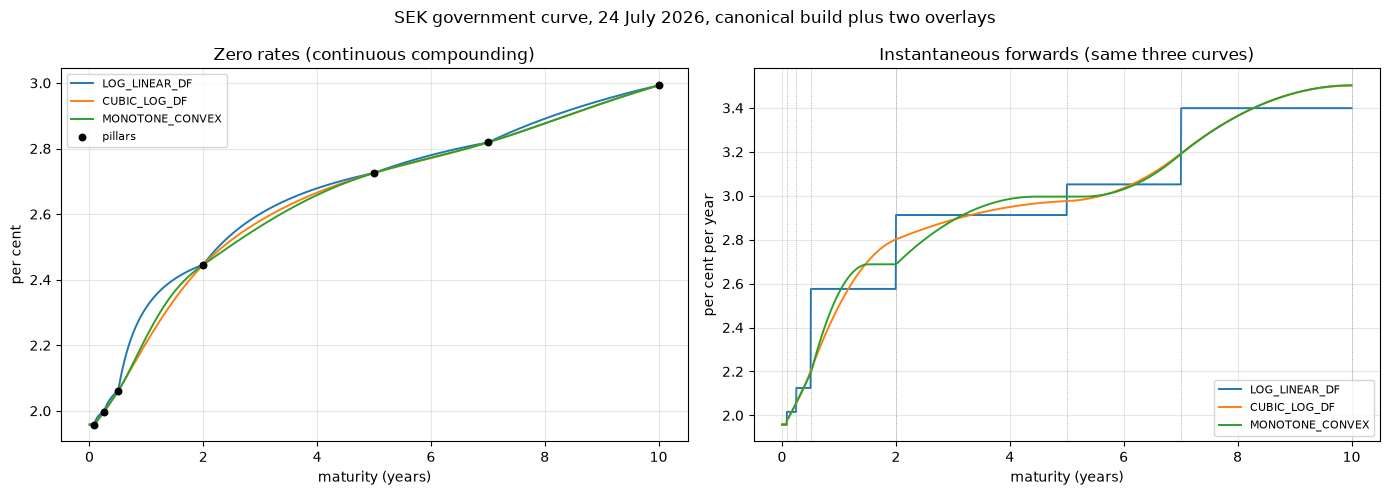

In [4]:
colours = {"LOG_LINEAR_DF": "#1f77b4", "CUBIC_LOG_DF": "#ff7f0e", "MONOTONE_CONVEX": "#2ca02c"}

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for name, series in zeros.items():
    axes[0].plot(grid, 100 * series, label=name, color=colours[name], lw=1.4)
axes[0].scatter(
    pillars,
    [100 * canonical.zero(t) for t in pillars],
    color="black",
    zorder=3,
    s=22,
    label="pillars",
)
axes[0].set_title("Zero rates (continuous compounding)")
axes[0].set_xlabel("maturity (years)")
axes[0].set_ylabel("per cent")

for name, series in fwds.items():
    axes[1].plot(grid, 100 * series, label=name, color=colours[name], lw=1.4)
for t in pillars:
    axes[1].axvline(t, color="#999999", lw=0.6, ls=":")
axes[1].set_title("Instantaneous forwards (same three curves)")
axes[1].set_xlabel("maturity (years)")
axes[1].set_ylabel("per cent per year")

for ax in axes:
    ax.grid(alpha=0.3)
    ax.legend(fontsize=8)
fig.suptitle("SEK government curve, 24 July 2026, canonical build plus two overlays")
fig.tight_layout()
plt.show()

In [5]:
# ## Results
#
# **The forward differences are about four times the zero differences.** Against
# monotone convex, log-linear differs by at most 9.57 basis points in zero rate
# terms and 38.23 basis points in forward terms. The cubic spline differs by 2.55
# and 11.37 basis points respectively. The ratio is the point: the same
# disagreement between two curves is roughly four times larger when measured on the
# quantity that is a derivative of the fitted object.
#
# **The disagreement is concentrated in the one region with no quote.** Every
# maximum in the table above falls between 0.51 and 2.00 years. That interval is
# precisely the gap identified in notebook 01, between the 6 month bill and the
# 2 year benchmark, left open because the 12 month bill series was discontinued
# in 2010. Where quotes are dense the rules have little room to differ; where the
# market is silent the rule is doing all the talking, and the choice of rule
# becomes a first order input.
#
# **The forward curves differ in shape, not only in level.** `LOG_LINEAR_DF`
# produces the step function visible in the right hand panel: constant forward
# within each pillar segment, discontinuous jump at each pillar. This follows
# directly from the rule. If $\log P$ is linear in $t$ on a segment then its
# derivative is constant there, so the forward is constant, and at the pillar the
# slope changes so the forward jumps. The dotted vertical lines mark the pillars,
# and every jump sits on one.
#
# **The cubic spline is smooth but not local.** A natural cubic spline through the
# log discount factors is twice differentiable, so its forward curve is
# continuous. The cost is that the spline coefficients are the solution of a
# global linear system: moving one quote changes the curve at every maturity,
# including maturities on the far side of other pillars. The overshoot this
# produces is what monotone convex is designed to suppress.
#
# **The quote residuals are consistent with the gaps.** The canonical build
# reprices every quote exactly. The overlays' measured residuals, up to about 0.17
# basis points on the bonds, are the same gap structure expressed in repricing
# terms: the residual is largest where a coupon falls in the sparse 6 month to 2
# year region and at the longest bond, whose coupons span the whole grid.
#
# ## Interpretation
#
# The economic content is that a forward curve is a statement about what the
# market implies for future short rates. A sawtooth forward curve asserts that the
# expected overnight rate is flat for three years and then jumps discontinuously
# on the day a benchmark bond happens to mature. No plausible model of monetary
# policy generates that path. The step is an artefact of the pillar grid, not
# information.
#
# This has practical consequences in three places. Products priced off forwards,
# such as caps, floors and forward starting swaps, inherit the artefact directly.
# Key rate durations, computed in notebook 05 by perturbing the curve at one
# pillar, depend on how far a bump propagates, which is a property of the
# interpolation rule. And a curve refitted daily under a non-local rule will show
# phantom moves at maturities where nothing was quoted differently.
#
# ## Limitations
#
# All three schemes assume there is a unique smooth curve to find. In fact
# infinitely many curves pass through the seven points, and only the interpolation
# rule selects one. Where data are dense the choice is inconsequential; where data
# are sparse the choice drives the output. The extrapolation beyond 10 years is
# unobserved — an unobservable input under IFRS 13 — and should not be relied
# upon. The forward curve is the diagnostic for interpolation quality, but it is
# not directly observable; the zero rate is aggregated and smooth. Disagreement in
# the forward curve translates to roughness in value and risk measurements when
# products are priced off instantaneous forwards or their derivatives.
#
# ## Regulatory context
#
# Neither Basel nor IFRS prescribes an interpolation scheme, and it would be
# surprising if they did. What the supervisory framework asks for is that the choice
# be documented and applied consistently.
#
# Under **BCBS d368**, the IRRBB standard requires a bank's yield-curve
# methodology to be documented, consistently applied and capable of independent
# review. An interpolation rule is one of those assumptions. In the EU the same
# management expectations are carried by CRD Article 84 and EBA/GL/2018/02; the
# scenario side of the framework is DR (EU) 2024/856, which notebook 05 applies.
# This notebook is an educational illustration of the documentation discipline,
# not a submission to any supervisory process.
#
# Under **CRR Article 105** on prudent valuation, institutions must hold
# additional valuation adjustments where the market prices of the positions they
# hold are uncertain. Where two defensible interpolation rules give different
# values for the same position, that dispersion is a measure of model uncertainty
# — which is precisely the kind of uncertainty a prudent valuation framework
# exists to govern. But the measurement above is a notebook exhibit: it is not an
# AVA calculation, it makes no capital statement, and no capital treatment is
# implied by anything in this repository.
#
# Under **IFRS 13**, an input that cannot be observed in the market is a Level 3
# input regardless of how standard the technique using it is. The interpolation
# rule is unobservable in exactly this sense. No automatic classification of any
# measurement follows from that: the hierarchy level of a fair-value measurement
# depends on the significance of the lowest-level significant input (IFRS
# 13.72-74), and this notebook performs no entity-level fair-value measurement.
#
# ## Summary
#
# The same seven quotes were calibrated into a canonical log-linear curve, and the
# two comparative overlays were built on its nodes. The three curves agree at the
# pillars by construction; between pillars they differ by up to 9.57 basis points
# in zero rate terms and 38.23 basis points in forward terms, and every one of
# those maxima falls in the 6 month to 2 year gap where no quote exists.
#
# The quote residuals tell the same story in repricing terms. The canonical build
# reprices all seven quotes exactly (measured, enforced). The overlays leave
# measured residuals of up to about 0.17 basis points on the bonds, concentrated
# where a coupon payment falls between pillars; the bill quotes are recovered
# exactly by all three rules because a bill has a single cash flow.
#
# Two conclusions follow. The forward curve is the diagnostic to inspect when
# assessing an interpolation scheme, because the zero curve understates the
# disagreement by roughly a factor of four. And the cost of the choice is
# concentrated where the data is thin, which is the region a valuation control
# function should be asked about first. The remaining notebooks use the canonical
# log-linear curve throughout.